# Défi quotidien : Prédiction du cancer du sein

## 1. Analyse exploratoire des données (EDA)

In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Chargez le jeu de données sur le cancer du sein depuis scikit-learn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target

# Les étiquettes originales (Maligne/Bénigne) sont stockées dans data.target_names
# Pour l'instant, les valeurs 0 et 1 suffisent pour la classification.
# Si vous souhaitez les remapper en chaînes de caractères, vous pouvez décommenter la ligne ci-dessous:
# df['diagnosis'] = df['diagnosis'].map(lambda x: data.target_names[x])

print("Premières lignes du jeu de données :")
display(df.head())

Premières lignes du jeu de données :


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Informations sur le jeu de données et valeurs manquantes :")
# Vérifiez les informations générales du DataFrame, y compris les types de données et les valeurs non nulles.
df.info()

# Vérifiez le nombre de valeurs manquantes par colonne.
print("\nNombre de valeurs manquantes par colonne :")
display(df.isnull().sum())

Informations sur le jeu de données et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error           

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


## 2. Visualisation de la distribution des diagnostics

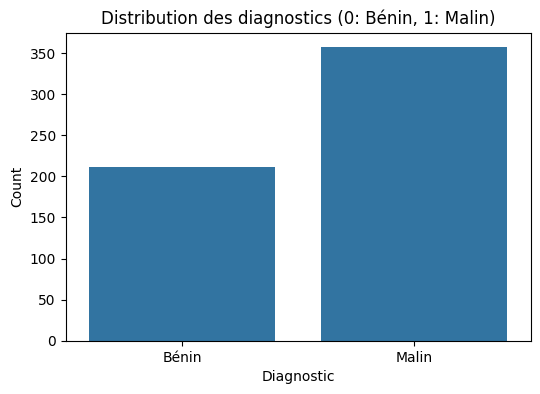

Nombre de lignes uniques dans la colonne 'diagnosis':


,count
diagnosis,
1,357
0,212


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créez un diagramme de comptage pour afficher le diagnostic
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution des diagnostics (0: Bénin, 1: Malin)')
plt.xlabel('Diagnostic')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Bénin', 'Malin'])
plt.show()

# Afficher le nombre de lignes uniques dans la colonne 'diagnosis'
print("Nombre de lignes uniques dans la colonne 'diagnosis':")
display(df['diagnosis'].value_counts())

## 3. Prétraitement des données, construction et évaluation des modèles

### Séparation des données en ensembles d'entraînement et de test

In [6]:
from sklearn.model_selection import train_test_split

# Séparer les caractéristiques (X) et la variable cible (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Séparer les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")
print(f"Distribution de la variable cible dans l'ensemble d'entraînement:\n{y_train.value_counts(normalize=True)}")
print(f"Distribution de la variable cible dans l'ensemble de test:\n{y_test.value_counts(normalize=True)}")

Taille de l'ensemble d'entraînement (X_train): (455, 30)
Taille de l'ensemble de test (X_test): (114, 30)
Distribution de la variable cible dans l'ensemble d'entraînement:
diagnosis
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Distribution de la variable cible dans l'ensemble de test:
diagnosis
1    0.631579
0    0.368421
Name: proportion, dtype: float64


### 1. Régression Logistique

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialiser et entraîner le modèle de régression logistique
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # solver 'liblinear' est bon pour les petits jeux de données
log_reg_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_lr = log_reg_model.predict(X_test)

# Calculer la précision
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Précision de la Régression Logistique : {accuracy_lr:.4f}")

Précision de la Régression Logistique : 0.9561


### 2. K plus proches voisins (KNN)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# Initialiser et entraîner le modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors est un paramètre courant à ajuster
knn_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_knn = knn_model.predict(X_test)

# Calculer la précision
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Précision de K plus proches voisins : {accuracy_knn:.4f}")

Précision de K plus proches voisins : 0.9123


### 3. Forêts aléatoires

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialiser et entraîner le modèle de Forêt Aléatoire
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_rf = rf_model.predict(X_test)

# Calculer la précision
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Précision des Forêts Aléatoires : {accuracy_rf:.4f}")

Précision des Forêts Aléatoires : 0.9561


### 4. Machines à Vecteurs de Support (SVM)

In [10]:
from sklearn.svm import SVC

# Initialiser et entraîner le modèle SVM
# Utilisation d'un kernel linéaire pour la simplicité, mais d'autres (rbf) pourraient être meilleurs.
svm_model = SVC(random_state=42, kernel='linear')
svm_model.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred_svm = svm_model.predict(X_test)

# Calculer la précision
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Précision des Machines à Vecteurs de Support (SVM) : {accuracy_svm:.4f}")

Précision des Machines à Vecteurs de Support (SVM) : 0.9561


### Quel est le meilleur modèle ?

In [11]:
results = {
    "Régression Logistique": accuracy_lr,
    "K plus proches voisins": accuracy_knn,
    "Forêts Aléatoires": accuracy_rf,
    "SVM": accuracy_svm
}

best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("Accuracies des modèles :")
for model, accuracy in results.items():
    print(f"- {model}: {accuracy:.4f}")

print(f"\nLe meilleur modèle est {best_model_name} avec une précision de {best_accuracy:.4f}.")

Accuracies des modèles :
- Régression Logistique: 0.9561
- K plus proches voisins: 0.9123
- Forêts Aléatoires: 0.9561
- SVM: 0.9561

Le meilleur modèle est Régression Logistique avec une précision de 0.9561.
